In [1]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

/Users/deniz/.pyenv/versions/3.10.6/envs/climate-resilience-dashboard/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv("data/outputs/all_indicator_values.csv")


In [3]:
# Target
target = (
    df[df["indicator"] == "CompositeRisk"]
    [["country", "year", "value"]]
    .rename(columns={"value": "CompositeRisk"})
)

# Features
features = df[df["indicator"] != "CompositeRisk"].copy()


In [4]:
features = features.pivot(
    index=["country", "year"],
    columns="indicator",
    values="value"
).reset_index()

In [5]:
features

indicator,country,year,Capacity,Economic,Ecosystems,Exposure,Food,Governance,Habitat,Health,Infrastructure,Readiness,Sensitivity,Social,Vulnerability,Water
0,AFG,1995,0.893281,0.496497,0.515884,0.480512,0.665745,0.128090,0.602933,0.748302,0.355586,0.308182,0.419587,0.299958,0.591376,0.529692
1,AFG,1996,0.893892,0.496497,0.516995,0.480512,0.665583,0.128090,0.604235,0.748302,0.354484,0.308180,0.419307,0.299954,0.591385,0.528281
2,AFG,1997,0.894459,0.496497,0.518030,0.480512,0.665420,0.141392,0.605583,0.748302,0.353925,0.312614,0.419055,0.299952,0.591453,0.526853
3,AFG,1998,0.890161,0.496497,0.518156,0.480512,0.657103,0.154694,0.606909,0.748302,0.353710,0.317047,0.418794,0.299949,0.589820,0.525424
4,AFG,1999,0.885896,0.496497,0.518156,0.480512,0.648959,0.143689,0.608137,0.748302,0.352292,0.313378,0.419433,0.299947,0.588345,0.525585
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8551,ZWE,2036,0.588863,0.284908,0.499704,0.516912,0.572403,0.180663,0.560557,0.694479,0.315343,0.202295,0.410264,0.141314,0.501943,0.373934
8552,ZWE,2037,0.590097,0.285825,0.498560,0.516912,0.572504,0.181927,0.560353,0.694478,0.317924,0.203015,0.409847,0.141293,0.502245,0.374200
8553,ZWE,2038,0.591269,0.286647,0.497488,0.516912,0.572582,0.182927,0.560210,0.694477,0.320331,0.203615,0.409477,0.141271,0.502543,0.374514
8554,ZWE,2039,0.592382,0.287385,0.496494,0.516912,0.572643,0.183706,0.560125,0.694476,0.322576,0.204114,0.409147,0.141250,0.502835,0.374835


In [20]:
dataset = features.merge(target, on=["country", "year"])
dataset = dataset.set_index(["country", "year"])

# Exclude composite metrics that dominate the target
excluded_features = ["Vulnerability", "Readiness"]
dataset = dataset.drop(columns=excluded_features)

In [21]:
X = dataset.drop(columns=["CompositeRisk"], errors="ignore")
y = dataset["CompositeRisk"]

In [22]:
X

Capacity  Economic  Ecosystems  Exposure      Food  Governance  \
country year                                                                   
AFG     1995  0.893281  0.496497    0.515884  0.480512  0.665745    0.128090   
        1996  0.893892  0.496497    0.516995  0.480512  0.665583    0.128090   
        1997  0.894459  0.496497    0.518030  0.480512  0.665420    0.141392   
        1998  0.890161  0.496497    0.518156  0.480512  0.657103    0.154694   
        1999  0.885896  0.496497    0.518156  0.480512  0.648959    0.143689   
...                ...       ...         ...       ...       ...         ...   
ZWE     2036  0.588863  0.284908    0.499704  0.516912  0.572403    0.180663   
        2037  0.590097  0.285825    0.498560  0.516912  0.572504    0.181927   
        2038  0.591269  0.286647    0.497488  0.516912  0.572582    0.182927   
        2039  0.592382  0.287385    0.496494  0.516912  0.572643    0.183706   
        2040  0.593440  0.288048    0.495580  0.516912  0.572689    0.184303   

               Habitat    Health  Infrastructure  Sensitivity    Social  \
country year                                                              
AFG     1995  0.602933  0.748302        0.355586     0.419587  0.299958   
        1996  0.604235  0.748302        0.354484     0.419307  0.299954   
        1997  0.605583  0.748302        0.353925     0.419055  0.299952   
        1998  0.606909  0.748302        0.353710     0.418794  0.299949   
        1999  0.608137  0.748302        0.352292     0.419433  0.299947   
...                ...       ...             ...          ...       ...   
ZWE     2036  0.560557  0.694479        0.315343     0.410264  0.141314   
        2037  0.560353  0.694478        0.317924     0.409847  0.141293   
        2038  0.560210  0.694477        0.320331     0.409477  0.141271   
        2039  0.560125  0.694476        0.322576     0.409147  0.141250   
        2040  0.560087  0.694476        0.324668     0.408854  0.141228   

                 Water  
country year            
AFG     1995  0.529692  
        1996  0.528281  
        1997  0.526853  
        1998  0.525424  
        1999  0.525585  
...                ...  
ZWE     2036  0.373934  
        2037  0.374200  
        2038  0.374514  
        2039  0.374835  
        2040  0.375134  

[8556 rows x 12 columns]

In [23]:
y

country  year
AFG      1995    0.536668
         1996    0.536782
         1997    0.538087
         1998    0.537887
         1999    0.535653
                   ...   
ZWE      2036    0.447177
         2037    0.447461
         2038    0.447716
         2039    0.447946
         2040    0.448154
Name: CompositeRisk, Length: 8556, dtype: float64

In [24]:
test_years = 5

train = (
    dataset.groupby(level="country")
           .apply(lambda df: df.iloc[:-test_years])
           .reset_index(level=0, drop=True)
)

test = (
    dataset.groupby(level="country")
           .apply(lambda df: df.iloc[-test_years:])
           .reset_index(level=0, drop=True)
)

X_train = train.drop(columns="CompositeRisk")
y_train = train["CompositeRisk"]

X_test = test.drop(columns="CompositeRisk")
y_test = test["CompositeRisk"]

In [25]:
# No readiness correction needed because Readiness is excluded
X_corrected_train = X_train.copy()
X_corrected_test = X_test.copy()

In [26]:
# Approach A: Train on original indicators
rf_corrected = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

In [27]:
rf_corrected.fit(X_corrected_train, y_train)


,n_estimators,100
,criterion,'squared_error'
,max_depth,15
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [28]:
y_pred_corr = rf_corrected.predict(X_corrected_test)
r2_corrected = r2_score(y_test, y_pred_corr)
print(f"RF (excluding Vulnerability & Readiness): R² = {r2_corrected:.4f}")


RF (excluding Vulnerability & Readiness): R² = 0.9978


In [29]:
# Approach B: Train on PCA components
pca = PCA()
pca.fit(X_corrected_train)

X_pca_train = pca.transform(X_corrected_train)
X_pca_test = pca.transform(X_corrected_test)

rf_pca = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

rf_pca.fit(X_pca_train, y_train)
y_pred_pca = rf_pca.predict(X_pca_test)

# Compare performance
print("Original Indicators:")
print(f"  R² Score: {r2_score(y_test, y_pred_corr):.4f}")
print(f"  MAE: {mean_absolute_error(y_test, y_pred_corr):.4f}")

print("\nPCA Components:")
print(f"  R² Score: {r2_score(y_test, y_pred_pca):.4f}")
print(f"  MAE: {mean_absolute_error(y_test, y_pred_pca):.4f}")

/Users/deniz/.pyenv/versions/3.10.6/envs/climate-resilience-dashboard/lib/python3.10/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/deniz/.pyenv/versions/3.10.6/envs/climate-resilience-dashboard/lib/python3.10/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/deniz/.pyenv/versions/3.10.6/envs/climate-resilience-dashboard/lib/python3.10/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T
/Users/deniz/.pyenv/versions/3.10.6/envs/climate-resilience-dashboard/lib/python3.10/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/deniz/.pyenv/versions/3.10.6/envs/climate-resilience-dashboard/lib/python3.10/site-p

Original Indicators:
  R² Score: 0.9978
  MAE: 0.0017

PCA Components:
  R² Score: 0.9975
  MAE: 0.0016


In [30]:
feature_names = X.columns

In [31]:
# Feature importance
feature_names = X.columns

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "RF_Importance": rf_corrected.feature_importances_,
    "PC1_Loading": np.abs(pca.components_[0][:len(feature_names)])
}).sort_values("RF_Importance", ascending=False)

print(importance_df)

           Feature  RF_Importance  PC1_Loading
7           Health       0.336989     0.423258
4             Food       0.314121     0.348569
0         Capacity       0.104678     0.426136
3         Exposure       0.085762     0.097993
9      Sensitivity       0.047741     0.145631
8   Infrastructure       0.027750     0.057691
5       Governance       0.023548     0.504713
1         Economic       0.019934     0.251039
11           Water       0.013462     0.115923
2       Ecosystems       0.010298     0.165673
6          Habitat       0.008038     0.154796
10          Social       0.007680     0.317834


In [32]:
print(len(feature_names))
print(len(rf_corrected.feature_importances_))
print(len(pca.components_[0]))

12
12
12


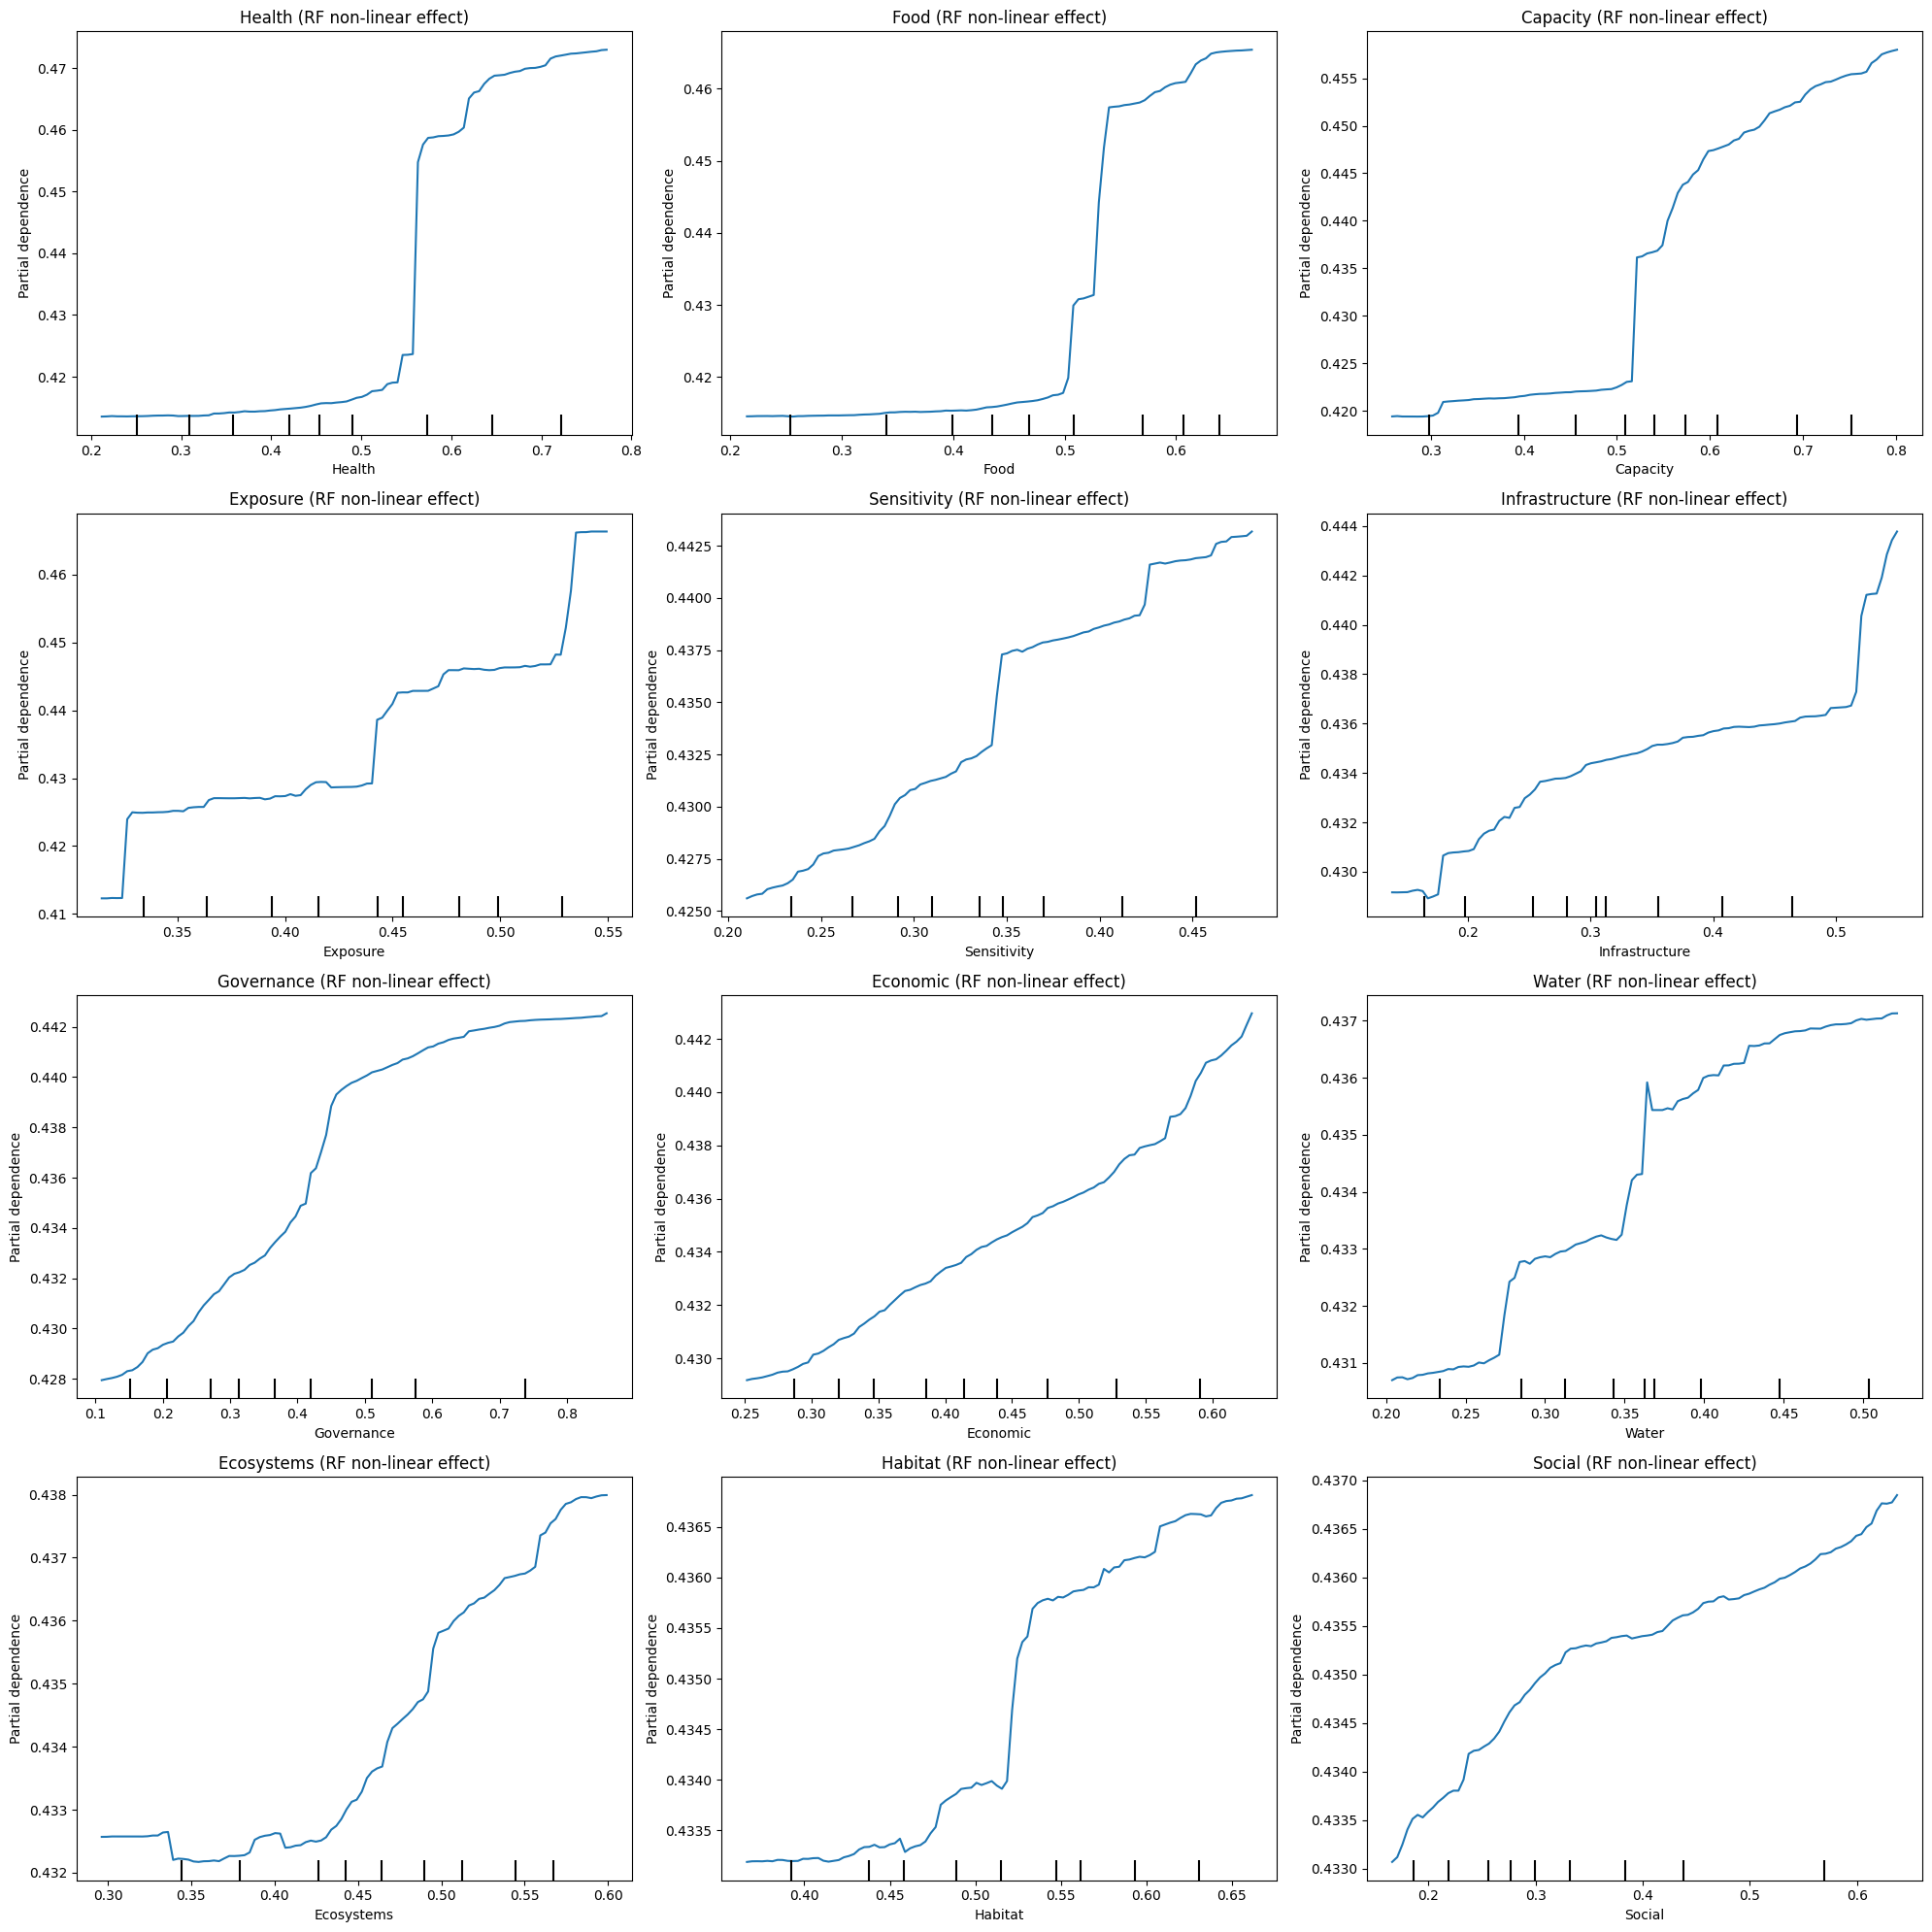

In [33]:
# Partial dependence plots for top 4 features (original approach)
fig, axes = plt.subplots(4, 3, figsize=(20, 20))
top_features_idx = importance_df.head(12).index.values

for idx, ax in enumerate(axes.flat):
    feature_idx = top_features_idx[idx]
    PartialDependenceDisplay.from_estimator(
        rf_corrected, X_corrected_test, [feature_idx], ax=ax
    )
    ax.set_title(f"{feature_names[feature_idx]} (RF non-linear effect)")

plt.tight_layout()
plt.show()

In [53]:
# Initialize SHAP explainer
explainer = shap.TreeExplainer(rf_corrected)  # Your corrected RF model

# Calculate SHAP values for all test data
shap_values = explainer.shap_values(X_corrected_test)

# Create base value (model's average prediction)
base_value = explainer.expected_value

explanation = shap.Explanation(
    values = shap_values,
    base_values=explainer.expected_value,
    feature_names=X_corrected_test.columns.tolist()
)

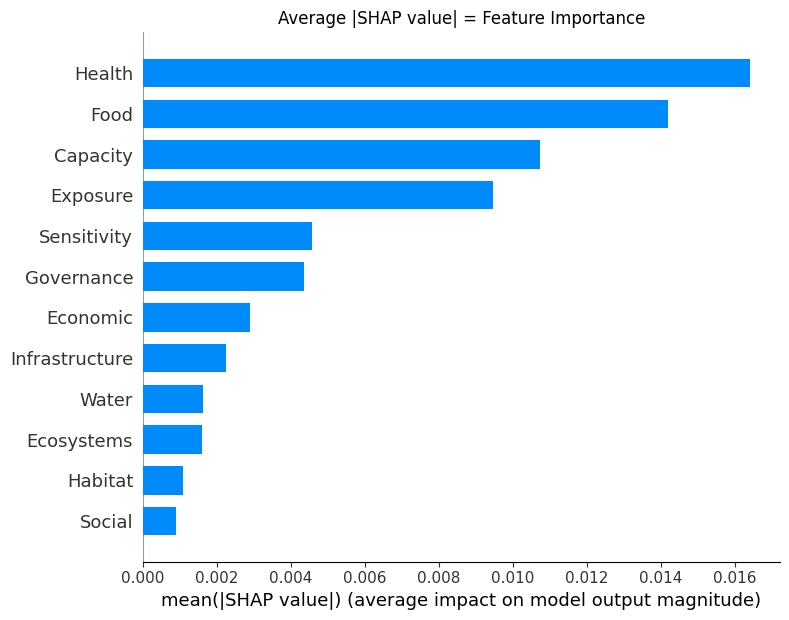

In [ ]:
# Bar plot: average absolute impact
plt.figure(figsize=(12, 6))
shap.summary_plot(
    shap_values,
    X_corrected_test,
    plot_type="bar",
    show=False
)
plt.title("Average |SHAP value| = Feature Importance")
plt.tight_layout()
plt.show()

In [ ]:
X_corrected_test.iloc[0:10,:]

Capacity  Economic  Ecosystems  Exposure      Food  Governance  \
country year                                                                   
AFG     2036  0.693118  0.294590    0.512293  0.480512  0.599771    0.119533   
        2037  0.694491  0.297982    0.512394  0.480512  0.600715    0.118864   
        2038  0.695842  0.301077    0.512484  0.480512  0.601608    0.118307   
        2039  0.697174  0.303901    0.512565  0.480512  0.602453    0.117843   
        2040  0.698485  0.306479    0.512637  0.480512  0.603251    0.117455   
AGO     2036  0.752054  0.233695    0.543362  0.543063  0.575920    0.175635   
        2037  0.752047  0.233455    0.543360  0.543063  0.576888    0.173895   
        2038  0.752039  0.233258    0.543360  0.543063  0.577811    0.172502   
        2039  0.752032  0.233096    0.543359  0.543063  0.578691    0.171389   
        2040  0.752027  0.232964    0.543359  0.543063  0.579531    0.170499   

               Habitat    Health  Infrastructure  Sensitivity    Social  \
country year                                                              
AFG     2036  0.566048  0.783486        0.303842     0.431856  0.339969   
        2037  0.567743  0.782774        0.304675     0.431739  0.338589   
        2038  0.569111  0.782167        0.305480     0.431651  0.337271   
        2039  0.570168  0.781649        0.306258     0.431584  0.336022   
        2040  0.570938  0.781208        0.307009     0.431534  0.334846   
AGO     2036  0.675208  0.602390        0.311406     0.275776  0.168665   
        2037  0.674715  0.601551        0.311428     0.275249  0.165168   
        2038  0.674217  0.600728        0.311431     0.274737  0.161928   
        2039  0.673762  0.599921        0.311425     0.274241  0.158966   
        2040  0.673302  0.599128        0.311417     0.273760  0.156295   

                 Water  
country year            
AFG     2036  0.504409  
        2037  0.505372  
        2038  0.506331  
        2039  0.507278  
        2040  0.508208  
AGO     2036  0.330221  
        2037  0.330203  
        2038  0.330189  
        2039  0.330179  
        2040  0.330172

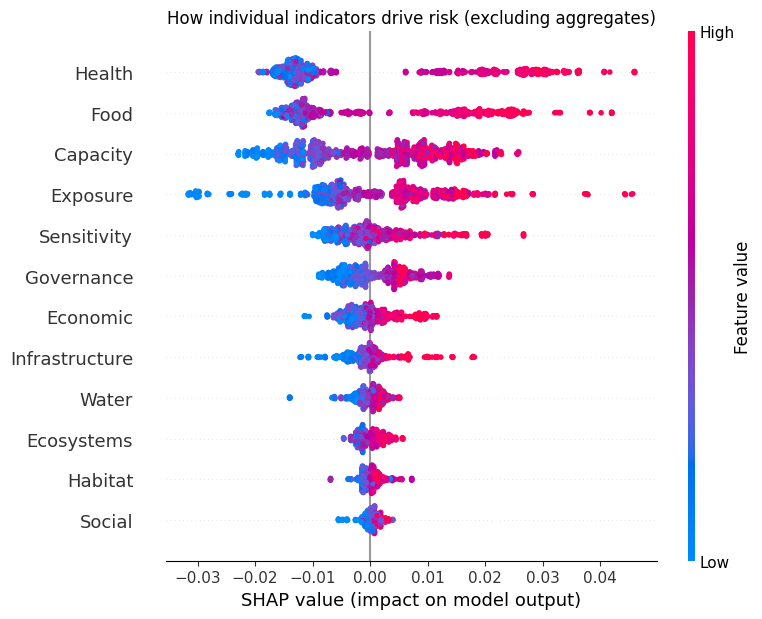

In [67]:
# Shows: high score → increases risk (right), low score → decreases risk (left)
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values,
    X_corrected_test,
    plot_type="dot",
    show=False
)
plt.title("How individual indicators drive risk (excluding aggregates)")
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

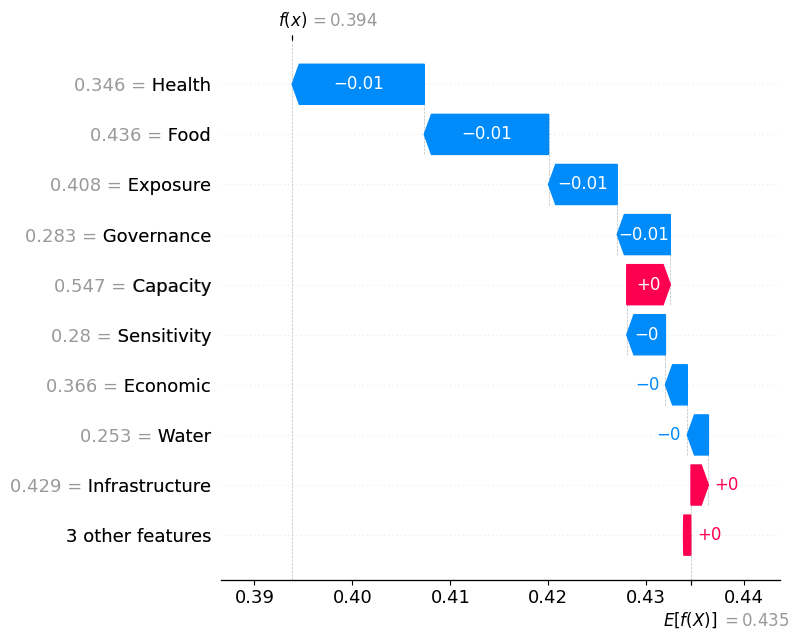

In [56]:
# Get SHAP values for a single country
country_idx = 10  # Pick a country
single_instance = X_corrected_test.iloc[country_idx:country_idx+1]
shap_values_single = explainer.shap_values(single_instance)

# Create waterfall plot correctly
explanation = shap.Explanation(
    values=shap_values_single[0],  # Get first (and only) row
    base_values=explainer.expected_value,
    data=single_instance.values[0],  # Convert to numpy array
    feature_names=X_corrected_test.columns.tolist()
)

plt.figure(figsize=(10, 6))
shap.waterfall_plot(explanation, show=False)
plt.tight_layout()
plt.show()

In [64]:
def explain_country_risk(country, model, explainer, data, year=None):

    # Get the requested row
    if year is None:
        row = data.loc[[country]].iloc[[0]]
    else:
        row = data.loc[[(country, year)]]

    # Prediction
    pred = model.predict(row)[0]

    # SHAP values
    shap_values = explainer.shap_values(row)

    explanation = (
        pd.DataFrame({
            "Feature": row.columns,
            "SHAP_Value": shap_values[0]
        })
        .sort_values("SHAP_Value", key=np.abs, ascending=False)
    )

    explanation["Contribution (%)"] = (
        explanation["SHAP_Value"].abs()
        / explanation["SHAP_Value"].abs().sum()
        * 100
    )

    print(f"\nPrediction: {pred:.4f}")
    print(f"Country: {row.index[0][0]}")
    print(f"Year: {row.index[0][1]}\n")

    return explanation

In [65]:
explain_country_risk("TCD", rf_corrected, explainer, X_corrected_test, year=2036)


Prediction: 0.5142
Country: TCD
Year: 2036



,Feature,SHAP_Value,Contribution (%)
7,Health,0.029010,28.311831
4,Food,0.024337,23.751154
0,Capacity,0.020053,19.570358
3,Exposure,0.011746,11.462793
1,Economic,-0.005359,5.230296
5,Governance,-0.004539,4.429954
2,Ecosystems,0.001909,1.863326
9,Sensitivity,0.001743,1.700636
11,Water,0.001613,1.574329
8,Infrastructure,-0.000967,0.943922


<Figure size 1000x600 with 0 Axes>

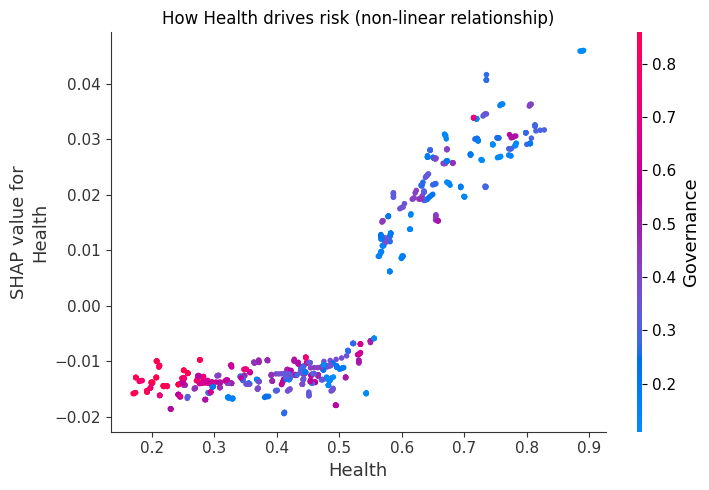

In [66]:
# Top contributor by SHAP impact
top_feature_idx = np.argsort(np.abs(shap_values).mean(axis=0))[-1]
top_feature_name = X_corrected_test.columns[top_feature_idx]

plt.figure(figsize=(10, 6))
shap.dependence_plot(
    top_feature_idx,
    shap_values,
    X_corrected_test,
    show=False
)
plt.title(f"How {top_feature_name} drives risk (non-linear relationship)")
plt.tight_layout()
plt.show()

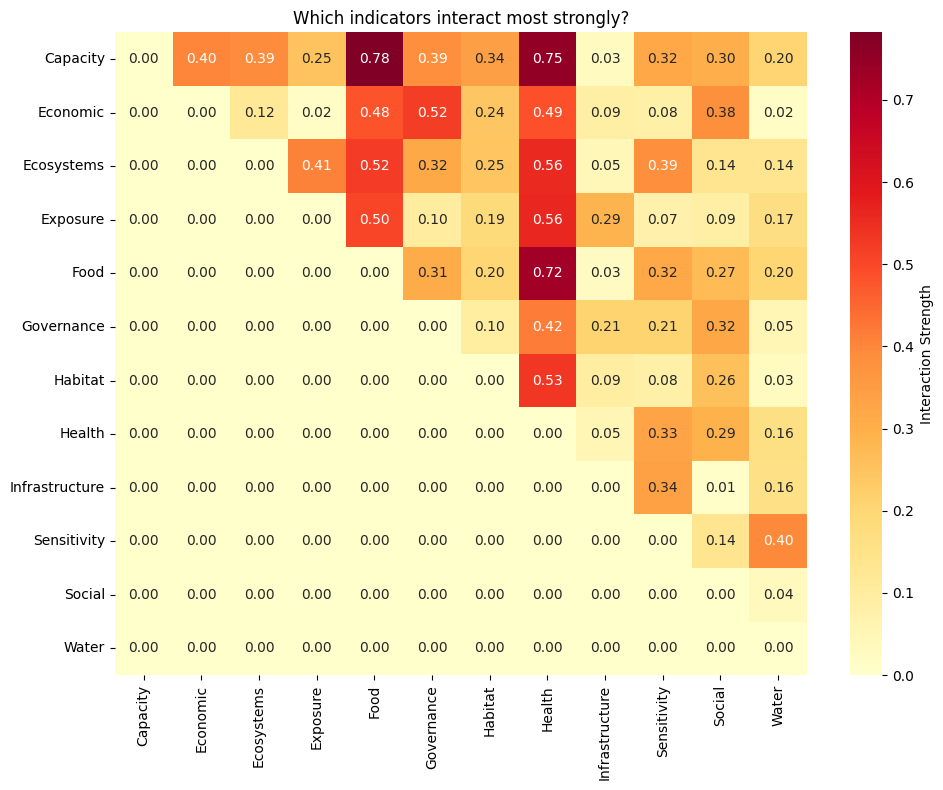

In [ ]:
import shap
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ============ FOCUS: Component-to-component interactions ============
# Exclude Vulnerability and Readiness from this analysis
components = [col for col in X_corrected_test.columns
              if col not in ['Vulnerability', 'Readiness']]

X_components_only = X_corrected_test[components]
shap_components = explainer.shap_values(X_components_only)


# ============ PLOT 2: Interaction heatmap ============
# Which component pairs interact most strongly?
interaction_matrix = np.zeros((len(components), len(components)))

for i, feat1 in enumerate(components):
    for j, feat2 in enumerate(components):
        if i < j:
            # Correlation between feature values × SHAP values = interaction proxy
            feat1_idx = X_corrected_test.columns.get_loc(feat1)
            feat2_idx = X_corrected_test.columns.get_loc(feat2)
            interaction = np.corrcoef(
                X_components_only[feat1].values,
                shap_components[:, feat2_idx]
            )[0, 1]
            interaction_matrix[i, j] = abs(interaction)

plt.figure(figsize=(10, 8))
import seaborn as sns
sns.heatmap(interaction_matrix, xticklabels=components, yticklabels=components,
            cmap='YlOrRd', annot=True, fmt='.2f', cbar_kws={'label': 'Interaction Strength'})
plt.title("Which indicators interact most strongly?")
plt.tight_layout()
plt.show()